# Chapter 5.7: Social and Heterogeneous Graph Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Model **social networks** as graphs for recommendation enhancement
2. Implement **DiffNet**: deep influence propagation on social networks
3. Understand **Heterogeneous Information Networks (HINs)** and multi-typed node/edge graphs
4. Implement **meta-path** based approaches for computing user-item similarity
5. Build **trust-aware** recommendation models with trust propagation
6. Combine social signals with collaborative filtering
7. Evaluate social recommendation and analyze influence patterns

## Prerequisites

- Chapter 5.5 (GNN for RecSys)
- Graph traversal concepts (BFS, random walks)
- PyTorch: sparse operations, message passing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part5/chapter_5.7_social_graphs.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part5/chapter_5.7_social_graphs.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random
from collections import defaultdict
import scipy.sparse as sp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Social Recommendation: Why Friends Matter

Social recommendation leverages the **social network** to enhance predictions:

- **Social influence**: Friends influence each other's preferences
- **Social homophily**: Friends tend to have similar tastes
- **Trust**: Users trust friends' recommendations more

> **💡 Concept:** Social recommendation models two types of graphs simultaneously: the **user-item interaction graph** (collaborative signal) and the **user-user social graph** (social signal). The key challenge is how to effectively combine these two sources of information.

## 2. Synthetic Social + Interaction Data

In [2]:
def generate_social_rec_data(n_users=300, n_items=200, n_interactions=4000,
                              n_social_edges=1500, seed=42):
    """Generate user-item interactions and social network with correlated preferences."""
    rng = np.random.RandomState(seed)
    
    n_groups = 10
    user_group = rng.randint(0, n_groups, size=n_users)
    n_categories = 15
    item_category = rng.randint(0, n_categories, size=n_items)
    
    # Group -> preferred categories
    group_prefs = {g: rng.choice(n_categories, size=3, replace=False).tolist()
                   for g in range(n_groups)}
    
    # Social network: more likely to connect within same group
    social_edges = set()
    while len(social_edges) < n_social_edges:
        u1 = rng.randint(0, n_users)
        if rng.random() < 0.7:  # 70% within-group friendship
            same_group = np.where(user_group == user_group[u1])[0]
            u2 = rng.choice(same_group)
        else:
            u2 = rng.randint(0, n_users)
        if u1 != u2:
            social_edges.add((min(u1, u2), max(u1, u2)))  # Undirected
    
    social_edges = [(u1, u2) for u1, u2 in social_edges]
    
    # User-item interactions (influenced by group preferences)
    user_items = defaultdict(set)
    interactions = []
    item_pop = rng.power(0.5, size=n_items)
    item_pop /= item_pop.sum()
    
    while len(interactions) < n_interactions:
        u = rng.randint(0, n_users)
        pref_cats = group_prefs[user_group[u]]
        if rng.random() < 0.65:
            cat = rng.choice(pref_cats)
            cat_items = np.where(item_category == cat)[0]
            if len(cat_items) > 0:
                probs = item_pop[cat_items]
                probs /= probs.sum()
                item = rng.choice(cat_items, p=probs)
            else:
                item = rng.choice(n_items, p=item_pop)
        else:
            item = rng.choice(n_items, p=item_pop)
        
        if item not in user_items[u]:
            user_items[u].add(int(item))
            interactions.append((u, int(item)))
    
    return {
        "interactions": interactions,
        "social_edges": social_edges,
        "n_users": n_users,
        "n_items": n_items,
        "user_items": user_items,
        "user_group": user_group,
        "item_category": item_category,
    }

data = generate_social_rec_data()
print(f"Users: {data['n_users']}, Items: {data['n_items']}")
print(f"Interactions: {len(data['interactions'])}")
print(f"Social edges: {len(data['social_edges'])}")

# Build adjacency structures
user_friends = defaultdict(set)
for u1, u2 in data["social_edges"]:
    user_friends[u1].add(u2)
    user_friends[u2].add(u1)

friend_counts = [len(user_friends[u]) for u in range(data["n_users"])]
print(f"Avg friends/user: {np.mean(friend_counts):.1f}")

Users: 300, Items: 200
Interactions: 4000
Social edges: 1500
Avg friends/user: 10.0


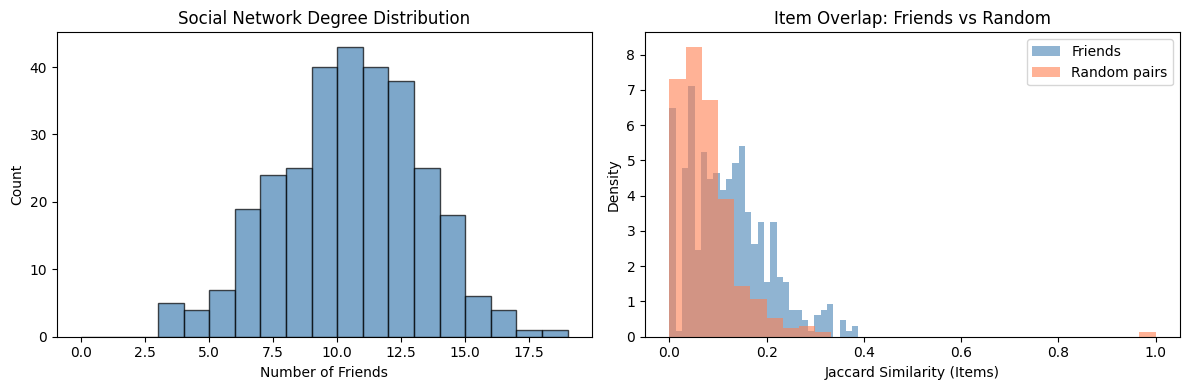

Mean Jaccard — Friends: 0.1210, Random: 0.0730


In [3]:
# Visualize social network structure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(friend_counts, bins=range(0, max(friend_counts) + 2),
             edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("Number of Friends")
axes[0].set_ylabel("Count")
axes[0].set_title("Social Network Degree Distribution")

# Measure social influence: jaccard similarity between friends' items
friend_jaccards = []
random_jaccards = []
rng = np.random.RandomState(42)
for u1, u2 in data["social_edges"][:500]:
    items1 = data["user_items"].get(u1, set())
    items2 = data["user_items"].get(u2, set())
    if items1 and items2:
        jacc = len(items1 & items2) / len(items1 | items2)
        friend_jaccards.append(jacc)
    # Random pair for comparison
    r1, r2 = rng.randint(0, data["n_users"], 2)
    ri1 = data["user_items"].get(r1, set())
    ri2 = data["user_items"].get(r2, set())
    if ri1 and ri2:
        random_jaccards.append(len(ri1 & ri2) / len(ri1 | ri2))

axes[1].hist(friend_jaccards, bins=30, alpha=0.6, label="Friends", color="steelblue", density=True)
axes[1].hist(random_jaccards, bins=30, alpha=0.6, label="Random pairs", color="coral", density=True)
axes[1].set_xlabel("Jaccard Similarity (Items)")
axes[1].set_ylabel("Density")
axes[1].set_title("Item Overlap: Friends vs Random")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Mean Jaccard — Friends: {np.mean(friend_jaccards):.4f}, Random: {np.mean(random_jaccards):.4f}")

## 3. Social Influence Propagation

The simplest approach: a user's preference is a weighted combination of their own preference and their friends' preferences:

$$\mathbf{e}_u^{\text{social}} = \mathbf{e}_u + \alpha \sum_{v \in \mathcal{F}_u} \frac{\mathbf{e}_v}{|\mathcal{F}_u|}$$

where $\mathcal{F}_u$ is user $u$'s friend set and $\alpha$ controls social influence strength.

In [4]:
def build_social_adj(social_edges, n_users):
    """Build normalized social adjacency matrix."""
    row, col = [], []
    for u1, u2 in social_edges:
        row.extend([u1, u2])
        col.extend([u2, u1])
    
    data_vals = np.ones(len(row))
    adj = sp.coo_matrix((data_vals, (row, col)), shape=(n_users, n_users)).tocsr()
    
    # Symmetric normalization
    degrees = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(degrees + 1e-8, -0.5)
    D_inv_sqrt = sp.diags(d_inv_sqrt)
    norm_adj = D_inv_sqrt @ adj @ D_inv_sqrt
    
    norm_adj = norm_adj.tocoo()
    indices = torch.tensor(np.vstack([norm_adj.row, norm_adj.col]), dtype=torch.long)
    values = torch.tensor(norm_adj.data, dtype=torch.float)
    return torch.sparse_coo_tensor(indices, values, (n_users, n_users))

social_adj = build_social_adj(data["social_edges"], data["n_users"])
print(f"Social adjacency matrix: {social_adj.shape}, nnz: {social_adj._nnz()}")

Social adjacency matrix: torch.Size([300, 300]), nnz: 3000


## 4. DiffNet: Deep Influence Propagation

**DiffNet** (Wu et al., SIGIR 2019) models social influence through deep propagation:

$$\mathbf{h}_u^{(l+1)} = \sigma\left(\mathbf{W}^{(l)} \cdot \text{AGG}\left(\{\mathbf{h}_v^{(l)} : v \in \mathcal{F}_u\}\right) + \mathbf{h}_u^{(l)}\right)$$

Key components:
1. **Influence diffusion layers**: Propagate user representations on social graph
2. **Interest diffusion layers**: Propagate on user-item graph
3. **Fusion**: Combine social and interest representations

> **⚠️ Common Pitfall:** Not all friends have equal influence. DiffNet++ extends DiffNet with attention-weighted social influence, where influence strength is learned from user similarities.

In [5]:
class DiffNet(nn.Module):
    """DiffNet: Deep Influence Propagation (Wu et al., 2019)."""
    
    def __init__(self, n_users, n_items, embed_dim=64, n_layers=2):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        
        # Social influence layers
        self.social_layers = nn.ModuleList([
            nn.Linear(embed_dim, embed_dim) for _ in range(n_layers)
        ])
        
        # Interest propagation layers
        self.interest_layers = nn.ModuleList([
            nn.Linear(embed_dim, embed_dim) for _ in range(n_layers)
        ])
        
        # Fusion
        self.fusion = nn.Linear(embed_dim * 2, embed_dim)
        
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    
    def forward(self, social_adj, ui_adj):
        """
        social_adj: (n_users, n_users) normalized social adjacency
        ui_adj: (n_users+n_items, n_users+n_items) normalized bipartite adjacency
        Returns: (user_embs, item_embs)
        """
        # Social influence diffusion
        h_social = self.user_emb.weight
        social_layers_out = [h_social]
        for layer in self.social_layers:
            neighbor_agg = torch.sparse.mm(social_adj, h_social)
            h_social = F.relu(layer(neighbor_agg) + h_social)
            social_layers_out.append(h_social)
        
        # Interest diffusion (LightGCN-style on user-item graph)
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        interest_layers_out = [all_emb]
        for layer in self.interest_layers:
            all_emb = torch.sparse.mm(ui_adj, all_emb)
            interest_layers_out.append(all_emb)
        
        # Average layer outputs
        social_final = torch.stack(social_layers_out, dim=0).mean(dim=0)  # (n_users, dim)
        interest_final = torch.stack(interest_layers_out, dim=0).mean(dim=0)
        interest_user = interest_final[:self.n_users]  # (n_users, dim)
        interest_item = interest_final[self.n_users:]  # (n_items, dim)
        
        # Fuse social and interest
        user_repr = self.fusion(torch.cat([social_final, interest_user], dim=-1))
        
        return user_repr, interest_item
    
    def predict(self, social_adj, ui_adj, user_ids, item_ids):
        user_embs, item_embs = self.forward(social_adj, ui_adj)
        u = user_embs[user_ids]
        i = item_embs[item_ids]
        return (u * i).sum(dim=-1)

print("DiffNet model defined.")

DiffNet model defined.


In [6]:
# Build user-item bipartite adjacency
N_USERS = data["n_users"]
N_ITEMS = data["n_items"]

train_interactions = data["interactions"][:3200]
test_interactions = data["interactions"][3200:]

train_user_items = defaultdict(set)
for u, i in train_interactions:
    train_user_items[u].add(i)

# Build bipartite adj
def build_bipartite_adj(interactions, n_users, n_items):
    n_nodes = n_users + n_items
    row, col, vals = [], [], []
    for u, i in interactions:
        row.extend([u, n_users + i])
        col.extend([n_users + i, u])
        vals.extend([1.0, 1.0])
    adj = sp.coo_matrix((vals, (row, col)), shape=(n_nodes, n_nodes)).tocsr()
    degrees = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(degrees + 1e-8, -0.5)
    D = sp.diags(d_inv_sqrt)
    norm = D @ adj @ D
    norm = norm.tocoo()
    idx = torch.tensor(np.vstack([norm.row, norm.col]), dtype=torch.long)
    val = torch.tensor(norm.data, dtype=torch.float)
    return torch.sparse_coo_tensor(idx, val, (n_nodes, n_nodes))

ui_adj = build_bipartite_adj(train_interactions, N_USERS, N_ITEMS)

# Train DiffNet
class BPRSocialDataset(Dataset):
    def __init__(self, interactions, n_items, user_items):
        self.interactions = interactions
        self.n_items = n_items
        self.user_items = user_items
    def __len__(self):
        return len(self.interactions)
    def __getitem__(self, idx):
        u, pos = self.interactions[idx]
        neg = random.randint(0, self.n_items - 1)
        while neg in self.user_items[u]:
            neg = random.randint(0, self.n_items - 1)
        return torch.tensor(u), torch.tensor(pos), torch.tensor(neg)

train_ds = BPRSocialDataset(train_interactions, N_ITEMS, train_user_items)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

torch.manual_seed(SEED)
diffnet = DiffNet(N_USERS, N_ITEMS, embed_dim=64, n_layers=2)
optimizer = torch.optim.Adam(diffnet.parameters(), lr=0.001)

losses = []
for epoch in range(15):
    diffnet.train()
    total_loss = 0
    n_b = 0
    for user, pos, neg in train_loader:
        u_emb, i_emb = diffnet(social_adj, ui_adj)
        pos_score = (u_emb[user] * i_emb[pos]).sum(-1)
        neg_score = (u_emb[user] * i_emb[neg]).sum(-1)
        loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8).mean()
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffnet.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        n_b += 1
    losses.append(total_loss / n_b)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/15 — Loss: {losses[-1]:.4f}")

Epoch 5/15 — Loss: 0.4755


Epoch 10/15 — Loss: 0.4326


Epoch 15/15 — Loss: 0.4371


In [7]:
@torch.no_grad()
def evaluate_social_rec(model, social_adj, ui_adj, test_interactions,
                        train_user_items, n_items, k=20):
    model.eval()
    u_emb, i_emb = model(social_adj, ui_adj)
    
    test_by_user = defaultdict(list)
    for u, i in test_interactions:
        test_by_user[u].append(i)
    
    hits = 0
    total = 0
    for u, items in test_by_user.items():
        scores = u_emb[u] @ i_emb.T
        for ti in train_user_items[u]:
            scores[ti] = -float("inf")
        _, topk = scores.topk(k)
        topk_set = set(topk.tolist())
        for ti in items:
            if ti in topk_set:
                hits += 1
            total += 1
    return hits / total

hr_diffnet = evaluate_social_rec(diffnet, social_adj, ui_adj, test_interactions,
                                  train_user_items, N_ITEMS)
print(f"DiffNet HR@20: {hr_diffnet:.4f}")

DiffNet HR@20: 0.2850


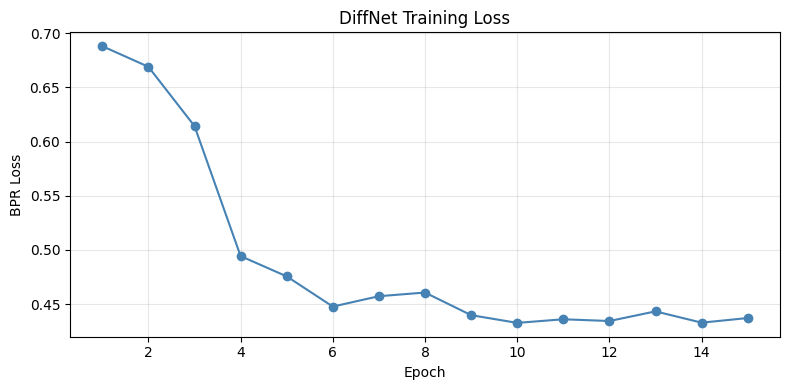

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses, marker="o", color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.title("DiffNet Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Meta-Path Based Approaches

In **Heterogeneous Information Networks (HINs)**, different types of nodes and edges coexist. A **meta-path** is a typed path pattern, e.g.:

- **User-Item-User (UIU)**: Users connected through shared items
- **User-User-Item (UUI)**: Items reachable through friends
- **Item-Category-Item (ICI)**: Items in the same category

Meta-path based similarity:

$$\text{PathSim}(u_1, u_2 | \mathcal{P}) = \frac{2 \times |\{p_{u_1 \rightsquigarrow u_2} : p \in \mathcal{P}\}|}{|\{p_{u_1 \rightsquigarrow \cdot} : p \in \mathcal{P}\}| + |\{p_{\cdot \rightsquigarrow u_2} : p \in \mathcal{P}\}|}$$

> **🔑 Pro Tip:** Meta-paths encode domain knowledge about meaningful connections. Different meta-paths capture different semantic relationships. Combining multiple meta-paths gives richer similarity signals.

In [9]:
class MetaPathSimilarity:
    """Compute meta-path based similarity between users."""
    
    def __init__(self, user_items, item_users, user_friends, item_category):
        self.user_items = user_items
        self.item_users = item_users
        self.user_friends = user_friends
        self.item_category = item_category
    
    def uiu_similarity(self, u1, u2):
        """User-Item-User: similarity through shared items."""
        shared = self.user_items.get(u1, set()) & self.user_items.get(u2, set())
        total = len(self.user_items.get(u1, set())) + len(self.user_items.get(u2, set()))
        if total == 0:
            return 0.0
        return 2 * len(shared) / total
    
    def uui_similarity(self, u1, u2):
        """User-User-Item: similarity through friend overlap."""
        shared_friends = self.user_friends.get(u1, set()) & self.user_friends.get(u2, set())
        total = len(self.user_friends.get(u1, set())) + len(self.user_friends.get(u2, set()))
        if total == 0:
            return 0.0
        return 2 * len(shared_friends) / total
    
    def uici_similarity(self, u1, u2):
        """User-Item-Category-Item-User: similarity through shared item categories."""
        cats1 = set(self.item_category[i] for i in self.user_items.get(u1, set()))
        cats2 = set(self.item_category[i] for i in self.user_items.get(u2, set()))
        shared = cats1 & cats2
        total = len(cats1) + len(cats2)
        if total == 0:
            return 0.0
        return 2 * len(shared) / total

# Build item->users mapping
item_users = defaultdict(set)
for u, i in train_interactions:
    item_users[i].add(u)

mp_sim = MetaPathSimilarity(train_user_items, item_users, user_friends, data["item_category"])

# Compare meta-path similarities for friend vs random pairs
friend_sims = {"UIU": [], "UUI": [], "UICI": []}
random_sims = {"UIU": [], "UUI": [], "UICI": []}

rng = np.random.RandomState(42)
for u1, u2 in data["social_edges"][:300]:
    friend_sims["UIU"].append(mp_sim.uiu_similarity(u1, u2))
    friend_sims["UUI"].append(mp_sim.uui_similarity(u1, u2))
    friend_sims["UICI"].append(mp_sim.uici_similarity(u1, u2))
    
    r1, r2 = rng.randint(0, N_USERS, 2)
    random_sims["UIU"].append(mp_sim.uiu_similarity(r1, r2))
    random_sims["UUI"].append(mp_sim.uui_similarity(r1, r2))
    random_sims["UICI"].append(mp_sim.uici_similarity(r1, r2))

print("Average meta-path similarities:")
for path in ["UIU", "UUI", "UICI"]:
    print(f"  {path}: Friends={np.mean(friend_sims[path]):.4f}, "
          f"Random={np.mean(random_sims[path]):.4f}")

Average meta-path similarities:
  UIU: Friends=0.1786, Random=0.1037
  UUI: Friends=0.1048, Random=0.0325
  UICI: Friends=0.5494, Random=0.4020


## 6. Trust-Aware Recommendation

In trust networks, edges carry **trust scores** (not just binary connections). Trust propagation:

$$\text{trust}(u \to v) = \begin{cases} t_{uv} & \text{if direct trust} \\ \max_{w \in \mathcal{F}_u} t_{uw} \cdot \text{trust}(w \to v) & \text{transitive trust} \end{cases}$$

> **💡 Concept:** Trust is directional and decays with propagation depth. Direct trust (1-hop) is stronger than transitive trust (multi-hop). Trust-aware models weight social influence by trust scores.

In [10]:
class TrustAwareRec(nn.Module):
    """Simple trust-aware recommendation model."""
    
    def __init__(self, n_users, n_items, embed_dim=64):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        
        # Trust weight for each friend (learned)
        self.trust_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  # Trust in [0, 1]
        )
        
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    
    def compute_trust(self, user_ids, friend_ids):
        """Compute trust scores between users and their friends."""
        u_emb = self.user_emb(user_ids)  # (batch, dim)
        f_emb = self.user_emb(friend_ids)  # (batch, n_friends, dim)
        
        # Expand user embedding to match friends
        u_expanded = u_emb.unsqueeze(1).expand_as(f_emb)
        combined = torch.cat([u_expanded, f_emb], dim=-1)
        trust = self.trust_mlp(combined).squeeze(-1)  # (batch, n_friends)
        return trust
    
    def get_social_emb(self, user_ids, friend_ids, friend_mask):
        """
        user_ids: (batch,)
        friend_ids: (batch, max_friends) padded
        friend_mask: (batch, max_friends) boolean, True for real friends
        """
        trust = self.compute_trust(user_ids, friend_ids)  # (batch, max_friends)
        trust = trust * friend_mask.float()  # Zero out padding
        trust = trust / (trust.sum(dim=-1, keepdim=True) + 1e-8)  # Normalize
        
        f_emb = self.user_emb(friend_ids)  # (batch, max_friends, dim)
        social_emb = (trust.unsqueeze(-1) * f_emb).sum(dim=1)  # (batch, dim)
        
        return self.user_emb(user_ids) + 0.5 * social_emb

trust_rec = TrustAwareRec(N_USERS, N_ITEMS, embed_dim=64)
print(f"TrustAwareRec params: {sum(p.numel() for p in trust_rec.parameters()):,}")

TrustAwareRec params: 36,161


## 7. Visualizing Social Influence

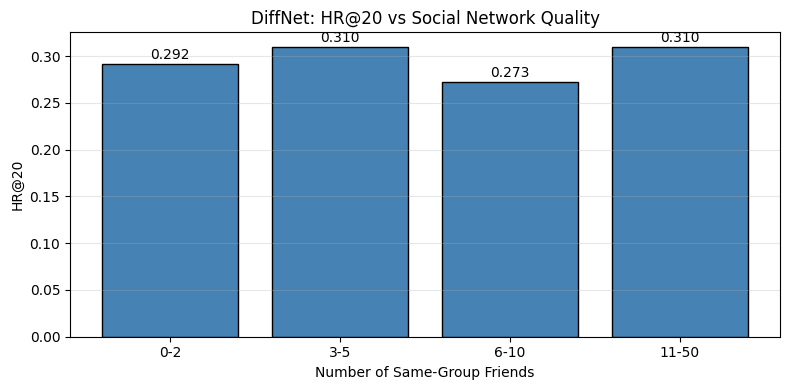

In [11]:
# Analyze: do users with more friends in the same group get better recommendations?
@torch.no_grad()
def analyze_social_benefit(model, social_adj, ui_adj, test_interactions,
                           train_user_items, user_friends, user_group, n_items):
    model.eval()
    u_emb, i_emb = model(social_adj, ui_adj)
    
    results = []  # (n_same_group_friends, hit)
    
    test_by_user = defaultdict(list)
    for u, i in test_interactions:
        test_by_user[u].append(i)
    
    for u, items in test_by_user.items():
        scores = u_emb[u] @ i_emb.T
        for ti in train_user_items[u]:
            scores[ti] = -float("inf")
        _, topk = scores.topk(20)
        topk_set = set(topk.tolist())
        
        n_same_friends = sum(1 for f in user_friends[u]
                             if user_group[f] == user_group[u])
        
        for ti in items:
            results.append((n_same_friends, 1 if ti in topk_set else 0))
    
    return results

results = analyze_social_benefit(
    diffnet, social_adj, ui_adj, test_interactions,
    train_user_items, user_friends, data["user_group"], N_ITEMS
)

# Group by friend count
from collections import Counter
bins = [(0, 2), (3, 5), (6, 10), (11, 50)]
bin_hr = []
bin_labels = []
for lo, hi in bins:
    group = [hit for n_f, hit in results if lo <= n_f <= hi]
    if group:
        bin_hr.append(np.mean(group))
        bin_labels.append(f"{lo}-{hi}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bin_labels, bin_hr, color="steelblue", edgecolor="black")
ax.set_xlabel("Number of Same-Group Friends")
ax.set_ylabel("HR@20")
ax.set_title("DiffNet: HR@20 vs Social Network Quality")
ax.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(bin_hr):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 8. Exercises

### 🏋️ Exercise 1: Implement Social Influence Propagation

In [12]:
# 🏋️ Exercise 1: Social Influence Propagation
#
# Implement a simple social recommender that:
# 1. Starts with user/item embeddings (MF)
# 2. Propagates user embeddings on the social graph (1-2 hops)
# 3. Uses the propagated embeddings for BPR prediction
#
# Compare with a baseline MF without social propagation.

class SocialMF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=64, social_weight=0.5):
        super().__init__()
        # TODO: Implement
        # 1. User embedding
        # 2. Item embedding
        # 3. Social propagation: u' = u + alpha * (social_adj @ u)
        # 4. Prediction: dot product of u' and item embedding
        pass
    
    def forward(self, social_adj, user_ids, pos_items, neg_items):
        # TODO: Return pos_scores, neg_scores
        pass

# TODO: Train and evaluate, compare with pure MF

### 🏋️ Exercise 2: Meta-Path Based Recommendation

In [13]:
# 🏋️ Exercise 2: Meta-Path Rec
#
# Build a meta-path based recommender that:
# 1. Computes UIU (User-Item-User) reachability matrix
# 2. For a target user, finds similar users via meta-paths
# 3. Recommends items liked by similar users
#
# Compare with random recommendation baseline.

def metapath_recommend(target_user, user_items, item_users, user_friends,
                       train_user_items, n_items, k=20):
    # TODO: Implement
    # 1. Find users connected to target_user via UIU path
    # 2. Rank candidate items by number of connected users who liked them
    # 3. Return top-k items (excluding training items)
    pass

# TODO: Evaluate on test set

### 🏋️ Exercise 3: Attention-Weighted Social Influence (DiffNet++)

In [14]:
# 🏋️ Exercise 3: DiffNet++ with Attention
#
# Extend DiffNet with attention-weighted social influence:
# Instead of uniform aggregation of friends, learn attention weights
# based on user embedding similarity.

class DiffNetPP(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=64, n_layers=2):
        super().__init__()
        # TODO: Implement
        # Same as DiffNet but with attention in social propagation:
        # alpha_{uv} = softmax(a^T [e_u || e_v])
        # h_u' = sum_v alpha_{uv} * W * h_v
        pass

# TODO: Train and compare with DiffNet

## Summary

| Method | Year | Graph Type | Key Idea |
|--------|------|-----------|----------|
| SocialMF | 2011 | Social + CF | Trust-regularized MF |
| DiffNet | 2019 | Social + Bipartite | Deep influence propagation |
| DiffNet++ | 2020 | Social + Bipartite | Attention-weighted propagation |
| Meta-path | Various | Heterogeneous | Semantic path-based similarity |
| TrustSVD | 2015 | Trust network | Trust-enhanced SVD |

**Key Takeaways:**
1. Social networks provide valuable signals for recommendation, especially for cold-start users
2. DiffNet propagates influence through multi-hop social connections
3. Meta-paths capture different semantic relationships in heterogeneous graphs
4. Trust-aware models weight social influence by trust scores
5. Social homophily (friends have similar tastes) is the key assumption
6. Next chapter: **Scalable Graph Recommendation** for industrial-scale systems